In [1]:
import os, sys, platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import nbformat, jupyter_core, IPython, ipykernel

ENVIRONMENT = os.environ.get('CONDA_DEFAULT_ENV', 'unknown')
print(f'Conda environment: {ENVIRONMENT}')
print(f'Python: {sys.version.split()[0]}')
print(f'NumPy: {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'nbformat: {nbformat.__version__}')
print(f'jupyter_core: {jupyter_core.__version__}')
print(f'IPython: {IPython.__version__}')
print(f'ipykernel: {ipykernel.__version__}')

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=6, suppress=True)


Fontconfig error: Cannot load default config file: No such file: (null)


Conda environment: base
Python: 3.13.9
NumPy: 2.3.5
Matplotlib: 3.10.6
nbformat: 5.10.4
jupyter_core: 5.8.1
IPython: 9.7.0
ipykernel: 6.31.0


# Complex exponentials, Itô calculus, and random walks

This notebook numerically checks the project's analytical formulas. It uses fixed, section-specific random seeds and is designed to execute top-to-bottom without hidden state. Numerical experiments support the derivations; they do not define stochastic differentials.

## 1. Brownian quadratic variation

For Gaussian increments on a uniform grid, `dW = sqrt(T/N) * xi`. An individual ratio `(dW)^2 / dt = xi^2` remains random. The accumulated sum has exact mean `T` and variance `2*T^2/N`, so it concentrates as the grid is refined.

 N     empirical mean   empirical var    exact mean   exact var
  16    0.995695         0.125839       1.000000     0.125000
  64    1.003809         0.031230       1.000000     0.031250
 256    0.999453         0.007599       1.000000     0.007812
1024    1.000604         0.001972       1.000000     0.001953


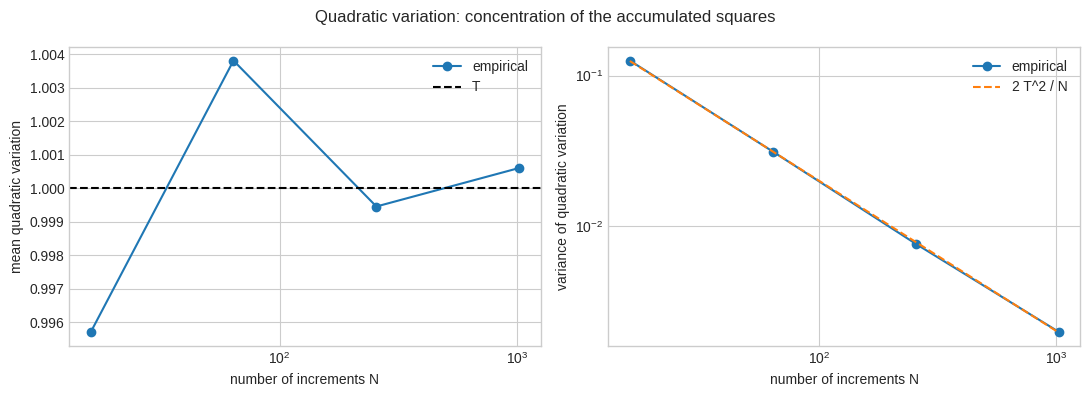

In [2]:
rng_qv = np.random.default_rng(2026072301)
T = 1.0
n_paths_qv = 12_000
qv_steps = np.array([16, 64, 256, 1024])
qv_rows = []

for n_steps in qv_steps:
    dt = T / n_steps
    # Sequential grid sizes keep peak memory moderate.
    dW = np.sqrt(dt) * rng_qv.standard_normal((n_paths_qv, n_steps))
    qv = np.sum(dW * dW, axis=1)
    qv_rows.append((n_steps, qv.mean(), qv.var(ddof=1), T, 2*T*T/n_steps))

print(' N     empirical mean   empirical var    exact mean   exact var')
for row in qv_rows:
    print(f'{row[0]:4d}    {row[1]:.6f}         {row[2]:.6f}       {row[3]:.6f}     {row[4]:.6f}')

qv_arr = np.asarray(qv_rows, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(qv_arr[:, 0], qv_arr[:, 1], 'o-', label='empirical')
axes[0].axhline(T, color='black', linestyle='--', label='T')
axes[0].set(xlabel='number of increments N', ylabel='mean quadratic variation')
axes[0].legend()
axes[1].loglog(qv_arr[:, 0], qv_arr[:, 2], 'o-', label='empirical')
axes[1].loglog(qv_arr[:, 0], qv_arr[:, 4], '--', label='2 T^2 / N')
axes[1].set(xlabel='number of increments N', ylabel='variance of quadratic variation')
axes[1].legend()
fig.suptitle('Quadratic variation: concentration of the accumulated squares')
fig.tight_layout()
plt.show()


## 2. Arithmetic diffusion

For `dX = mu dt + sigma dW`, the exact solution is `X_T = X_0 + mu*T + sigma*W_T`. We compare terminal Monte Carlo moments with the analytical normal distribution and report Monte Carlo standard errors.

In [3]:
rng_arith = np.random.default_rng(2026072302)
x0, mu_x, sigma_x, T_x = 0.3, 0.5, 0.8, 1.0
n_paths_arith = 200_000
x_terminal = x0 + mu_x*T_x + sigma_x*np.sqrt(T_x)*rng_arith.standard_normal(n_paths_arith)

mean_theory = x0 + mu_x*T_x
var_theory = sigma_x**2 * T_x
mean_emp = x_terminal.mean()
var_emp = x_terminal.var(ddof=1)
mean_se = np.sqrt(var_theory / n_paths_arith)
# For normal data, the unbiased sample variance has this exact standard deviation.
var_se = var_theory * np.sqrt(2/(n_paths_arith-1))

print(f'Empirical mean  = {mean_emp:.6f}; theory = {mean_theory:.6f}; MC SE = {mean_se:.6f}; z = {(mean_emp-mean_theory)/mean_se:.3f}')
print(f'Empirical var   = {var_emp:.6f}; theory = {var_theory:.6f}; MC SE = {var_se:.6f}; z = {(var_emp-var_theory)/var_se:.3f}')
print(f'95% MC interval for mean: [{mean_emp-1.96*mean_se:.6f}, {mean_emp+1.96*mean_se:.6f}]')


Empirical mean  = 0.801534; theory = 0.800000; MC SE = 0.001789; z = 0.858
Empirical var   = 0.640235; theory = 0.640000; MC SE = 0.002024; z = 0.116
95% MC interval for mean: [0.798028, 0.805040]


## 3. The stochastic exponential and geometric Brownian motion

For `dS = mu*S dt + sigma*S dW`, the exact solution is `S_T = S_0 exp((mu-sigma^2/2)T + sigma W_T)`. First we check its moments. Then we couple Euler–Maruyama and the exact solution using the same Brownian increments, which is essential for measuring strong error.

In [4]:
rng_gbm_mom = np.random.default_rng(2026072303)
s0, mu_s, sigma_s, T_s = 1.3, 0.2, 0.7, 1.0
n_paths_gbm_mom = 200_000
WT = np.sqrt(T_s) * rng_gbm_mom.standard_normal(n_paths_gbm_mom)
s_exact_sample = s0*np.exp((mu_s-0.5*sigma_s**2)*T_s + sigma_s*WT)
s_mean_theory = s0*np.exp(mu_s*T_s)
s_var_theory = s0**2*np.exp(2*mu_s*T_s)*(np.exp(sigma_s**2*T_s)-1)
s_mean_emp = s_exact_sample.mean()
s_var_emp = s_exact_sample.var(ddof=1)
s_mean_se = np.sqrt(s_var_theory/n_paths_gbm_mom)

print(f'Exact-sample mean = {s_mean_emp:.6f}; theory = {s_mean_theory:.6f}; mean MC SE = {s_mean_se:.6f}')
print(f'Exact-sample var  = {s_var_emp:.6f}; theory = {s_var_theory:.6f}')


Exact-sample mean = 1.587666; theory = 1.587824; mean MC SE = 0.002823
Exact-sample var  = 1.575308; theory = 1.594185


 N       dt          coupled MAE     coupled RMS
  16   0.0625000    0.1101493       0.1767281
  64   0.0156250    0.0545096       0.0860046
 256   0.0039062    0.0272612       0.0436000
1024   0.0009766    0.0138720       0.0223796
log-log MAE slope = 0.498; RMS slope = 0.496 (Euler strong order is 1/2)


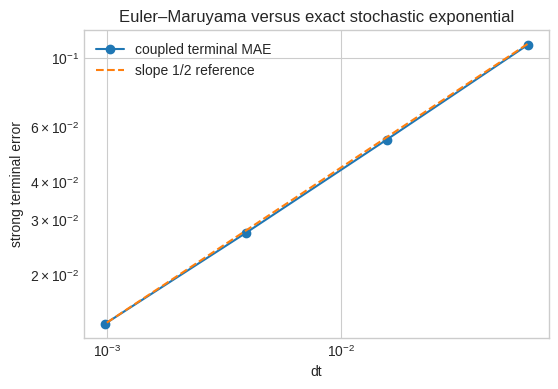

In [5]:
def gbm_coupled_error(n_steps, n_paths=20_000, batch_size=2_000, seed=0):
    rng = np.random.default_rng(seed)
    dt = T_s/n_steps
    abs_sum = 0.0
    sq_sum = 0.0
    count = 0
    for start in range(0, n_paths, batch_size):
        m = min(batch_size, n_paths-start)
        dW = np.sqrt(dt)*rng.standard_normal((m, n_steps))
        s_em = np.full(m, s0)
        for k in range(n_steps):
            s_em += mu_s*s_em*dt + sigma_s*s_em*dW[:, k]
        s_exact = s0*np.exp((mu_s-0.5*sigma_s**2)*T_s + sigma_s*dW.sum(axis=1))
        error = s_em-s_exact
        abs_sum += np.abs(error).sum()
        sq_sum += np.square(error).sum()
        count += m
    return abs_sum/count, np.sqrt(sq_sum/count)

gbm_steps = np.array([16, 64, 256, 1024])
gbm_errors = []
for j, n_steps in enumerate(gbm_steps):
    gbm_errors.append(gbm_coupled_error(n_steps, seed=2026072310+j))
gbm_errors = np.asarray(gbm_errors)
gbm_dt = T_s/gbm_steps
mae_slope = np.polyfit(np.log(gbm_dt), np.log(gbm_errors[:, 0]), 1)[0]
rms_slope = np.polyfit(np.log(gbm_dt), np.log(gbm_errors[:, 1]), 1)[0]

print(' N       dt          coupled MAE     coupled RMS')
for n_steps, dt, (mae, rms) in zip(gbm_steps, gbm_dt, gbm_errors):
    print(f'{n_steps:4d}   {dt:.7f}    {mae:.7f}       {rms:.7f}')
print(f'log-log MAE slope = {mae_slope:.3f}; RMS slope = {rms_slope:.3f} (Euler strong order is 1/2)')

plt.figure(figsize=(6, 4))
plt.loglog(gbm_dt, gbm_errors[:, 0], 'o-', label='coupled terminal MAE')
reference = gbm_errors[-1, 0]*(gbm_dt/gbm_dt[-1])**0.5
plt.loglog(gbm_dt, reference, '--', label='slope 1/2 reference')
plt.xlabel('dt')
plt.ylabel('strong terminal error')
plt.title('Euler–Maruyama versus exact stochastic exponential')
plt.legend()
plt.show()


## 4. Brownian phase and stochastic rotation

The exact phase model `Z_t = r_0 exp(i(theta_0 + beta W_t))` has constant radius. Its Itô SDE contains the inward drift `-beta^2 Z_t/2`. We compare the exact phase update, Euler–Maruyama for the correct SDE, and Euler–Maruyama after incorrectly omitting that drift.

Exact phase max |radius-r0|: 4.774e-15
Correct EM terminal mean |radius-r0|: 0.033914
Missing-drift EM terminal mean radius: 1.827472
Wrong-SDE exact radius prediction exp(beta^2*T/2): 1.831252
Correct EM terminal E|Z|^2: empirical 1.000402, finite-grid theory 1.000915
Missing EM terminal E|Z|^2: empirical 3.345654, finite-grid theory 3.347365


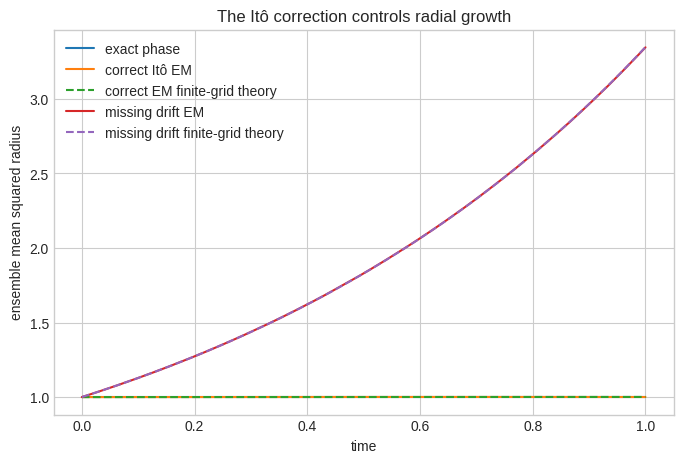

In [6]:
rng_rot = np.random.default_rng(2026072304)
r0, theta0, beta, T_r = 1.0, 0.4, 1.1, 1.0
n_steps_rot, n_paths_rot = 400, 30_000
dt = T_r/n_steps_rot
z_exact = np.full(n_paths_rot, r0*np.exp(1j*theta0), dtype=complex)
z_correct = z_exact.copy()
z_missing = z_exact.copy()
mean_sq_exact = np.empty(n_steps_rot+1)
mean_sq_correct = np.empty(n_steps_rot+1)
mean_sq_missing = np.empty(n_steps_rot+1)
mean_sq_exact[0] = mean_sq_correct[0] = mean_sq_missing[0] = r0**2

for k in range(n_steps_rot):
    dW = np.sqrt(dt)*rng_rot.standard_normal(n_paths_rot)
    z_exact *= np.exp(1j*beta*dW)
    z_correct += -0.5*beta**2*z_correct*dt + 1j*beta*z_correct*dW
    z_missing += 1j*beta*z_missing*dW
    mean_sq_exact[k+1] = np.mean(np.abs(z_exact)**2)
    mean_sq_correct[k+1] = np.mean(np.abs(z_correct)**2)
    mean_sq_missing[k+1] = np.mean(np.abs(z_missing)**2)

time_rot = np.linspace(0, T_r, n_steps_rot+1)
correct_grid_theory = r0**2*(1+0.25*beta**4*dt**2)**np.arange(n_steps_rot+1)
missing_grid_theory = r0**2*(1+beta**2*dt)**np.arange(n_steps_rot+1)

print(f'Exact phase max |radius-r0|: {np.max(np.abs(np.abs(z_exact)-r0)):.3e}')
print(f'Correct EM terminal mean |radius-r0|: {np.mean(np.abs(np.abs(z_correct)-r0)):.6f}')
print(f'Missing-drift EM terminal mean radius: {np.mean(np.abs(z_missing)):.6f}')
print(f'Wrong-SDE exact radius prediction exp(beta^2*T/2): {r0*np.exp(0.5*beta**2*T_r):.6f}')
print(f'Correct EM terminal E|Z|^2: empirical {mean_sq_correct[-1]:.6f}, finite-grid theory {correct_grid_theory[-1]:.6f}')
print(f'Missing EM terminal E|Z|^2: empirical {mean_sq_missing[-1]:.6f}, finite-grid theory {missing_grid_theory[-1]:.6f}')

plt.figure(figsize=(8, 5))
plt.plot(time_rot, mean_sq_exact, label='exact phase')
plt.plot(time_rot, mean_sq_correct, label='correct Itô EM')
plt.plot(time_rot, correct_grid_theory, '--', label='correct EM finite-grid theory')
plt.plot(time_rot, mean_sq_missing, label='missing drift EM')
plt.plot(time_rot, missing_grid_theory, '--', label='missing drift finite-grid theory')
plt.xlabel('time')
plt.ylabel('ensemble mean squared radius')
plt.title('The Itô correction controls radial growth')
plt.legend()
plt.show()


## 5. Planar Brownian motion in polar coordinates

For isotropic planar Brownian motion with Cartesian volatility `sigma`, the polar SDEs away from zero are `dR = sigma^2/(2R) dt + sigma dB_R` and `dTheta = sigma/R dB_Theta`. A one-step experiment at several radii checks the local drift and variance rates.

In [7]:
rng_planar = np.random.default_rng(2026072305)
sigma_p = 0.6
dt_p = 1e-3
n_local = 600_000
radii = [0.5, 1.0, 2.0]
print('r0    drift dR/dt (emp,theory)    var-rate dR (emp,theory)    var-rate dTheta (emp,theory)')
planar_rows = []
for radius in radii:
    dW1 = np.sqrt(dt_p)*rng_planar.standard_normal(n_local)
    dW2 = np.sqrt(dt_p)*rng_planar.standard_normal(n_local)
    z1 = radius + sigma_p*(dW1 + 1j*dW2)
    dR = np.abs(z1)-radius
    dTheta = np.angle(z1)
    drift_emp = dR.mean()/dt_p
    drift_theory = sigma_p**2/(2*radius)
    rvar_emp = dR.var(ddof=1)/dt_p
    rvar_theory = sigma_p**2
    tvar_emp = dTheta.var(ddof=1)/dt_p
    tvar_theory = sigma_p**2/radius**2
    planar_rows.append((radius, drift_emp, drift_theory, rvar_emp, rvar_theory, tvar_emp, tvar_theory))
    print(f'{radius:3.1f}    ({drift_emp:.4f}, {drift_theory:.4f})          ({rvar_emp:.4f}, {rvar_theory:.4f})             ({tvar_emp:.4f}, {tvar_theory:.4f})')


r0    drift dR/dt (emp,theory)    var-rate dR (emp,theory)    var-rate dTheta (emp,theory)
0.5    (0.4127, 0.3600)          (0.3599, 0.3600)             (1.4405, 1.4400)
1.0    (0.2069, 0.1800)          (0.3596, 0.3600)             (0.3603, 0.3600)
2.0    (0.0942, 0.0900)          (0.3587, 0.3600)             (0.0899, 0.0900)


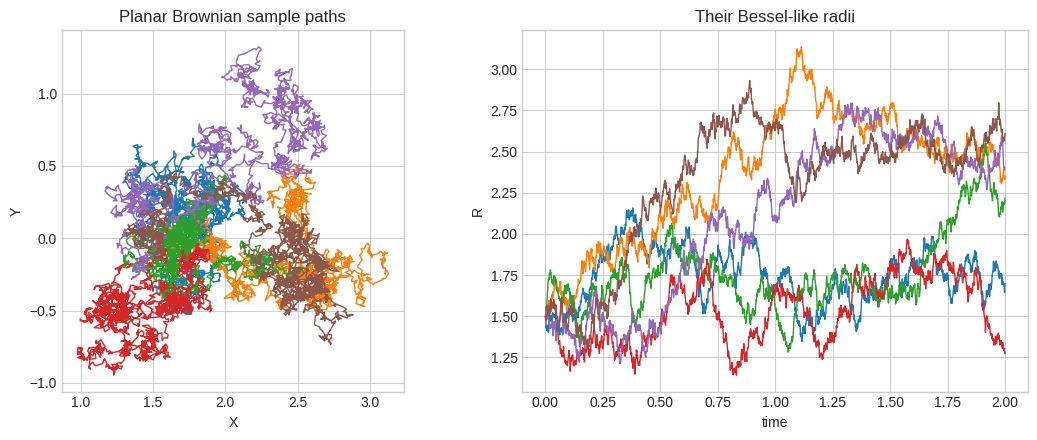

In [8]:
rng_paths = np.random.default_rng(2026072306)
n_show, n_steps_show, T_show = 6, 2_000, 2.0
dt_show = T_show/n_steps_show
increments = sigma_p*np.sqrt(dt_show)*(rng_paths.standard_normal((n_show, n_steps_show)) + 1j*rng_paths.standard_normal((n_show, n_steps_show)))
paths = np.column_stack([np.full(n_show, 1.5+0j), 1.5 + np.cumsum(increments, axis=1)])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for path in paths:
    axes[0].plot(path.real, path.imag, linewidth=1)
    axes[1].plot(np.linspace(0, T_show, n_steps_show+1), np.abs(path), linewidth=1)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set(xlabel='X', ylabel='Y', title='Planar Brownian sample paths')
axes[1].set(xlabel='time', ylabel='R', title='Their Bessel-like radii')
fig.tight_layout()
plt.show()


## 6. Numerical conclusions

- Individual Brownian squares remain random, but their accumulated sum concentrates at `T` with variance `2*T^2/N`.
- Arithmetic-diffusion and geometric-Brownian terminal moments agree with their analytic laws within Monte Carlo error.
- Coupled Euler–Maruyama error decreases at approximately its predicted strong order.
- Exact Brownian phase preserves radius. Correct Itô Euler has only a finite-grid radial bias, while omitting the `-beta^2/2` drift produces order-one exponential growth.
- Planar Brownian radial drift and angular variance depend on radius as the polar Itô equations predict.

In [9]:
# Broad deterministic sanity checks: failures indicate a formula/code regression,
# not a statistical proof.
assert abs(qv_rows[-1][1]-T) < 0.01
assert abs(mean_emp-mean_theory) < 4*mean_se
assert abs(var_emp-var_theory) < 5*var_se
assert abs(s_mean_emp-s_mean_theory) < 5*s_mean_se
assert gbm_errors[-1, 0] < gbm_errors[0, 0]
assert 0.30 < mae_slope < 0.75
assert np.max(np.abs(np.abs(z_exact)-r0)) < 1e-10
assert mean_sq_missing[-1] > 2.5*mean_sq_correct[-1]
for row in planar_rows:
    assert abs(row[3]-row[4])/row[4] < 0.03
    assert abs(row[5]-row[6])/row[6] < 0.04
print('All deterministic numerical sanity checks passed.')


All deterministic numerical sanity checks passed.
